# Práctica 4 - Modelo Predictivo de Clasificación

**Autores:** Mariana Urrego, Natalia Urrego, Sebastián Villa, Steve Ellis

El objetivo de este notebook es entrenar varios modelos de clasificación para predecir si una sesión de red corresponde a un ataque (`attack_detected`), comparar su rendimiento y guardar el mejor para su posterior despliegue.

El dataset de entrada (`DatosLimpiosP4.xlsx`) proviene del proceso de calidad de datos de la práctica anterior.

**Pasos del notebook:**
1. Preparación de datos
2. División 70-30
3. Entrenamiento y evaluación de modelos
4. Selección del mejor modelo e hiperparametrización
5. Entrenamiento final y guardado del modelo

*El despliegue se realiza en un notebook separado.*

# Predicción de detección de ataques ciberneticos  (Clasificación)

1. Preparación de Datos
2. División de los datos 70-30
3. Aprendizaje del Modelo
4. Evaluación del Modelo: matriz de confusion, P,R, ROC
5. Guardar el modelo

* El despliegue se realiza en otro jupyter_notebook

### Librerías

- `pandas` — manipulación de datos
- `numpy` — operaciones matemáticas
- `matplotlib` — visualización

In [ ]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

# 1. Preparación de Datos

Antes de entrenar cualquier modelo es necesario dejar los datos en el formato correcto. En este paso se realizan las siguientes acciones:

1. Carga del dataset limpio desde Excel.
2. Corrección de tipos de datos: las columnas de texto se convierten a `category`.
3. Visualización exploratoria para revisar distribuciones y posibles anomalías.
4. Balanceo de clases con SMOTE.
5. Codificación de variables categóricas con dummies y LabelEncoder.

In [ ]:
data = pd.read_excel("DatosLimpiosP4.xlsx", keep_default_na=False)
data.head()

,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,attack_detected
0,4,492.983263,DES,0.606818,1,Edge,1
1,3,1557.996461,DES,0.301569,0,Firefox,0
2,3,75.044262,DES,0.739164,2,Chrome,1
3,4,601.248835,DES,0.123267,0,Unknown,1
4,5,532.540888,AES,0.054874,1,Firefox,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   login_attempts       9537 non-null   int64  
 1   session_duration     9537 non-null   float64
 2   encryption_used      9537 non-null   object 
 3   ip_reputation_score  9537 non-null   float64
 4   failed_logins        9537 non-null   int64  
 5   browser_type         9537 non-null   object 
 6   attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 521.7+ KB


### Corrección de Tipos de Datos

Se detectó que la variable `attack_detected` (la variable objetivo) se cargó inicialmente como tipo `int`, pero para el análisis y modelado de clasificación, es más apropiado tratarla como una variable `category`. Esta corrección asegura que pandas y las librerías de ML la interpreten correctamente.

In [ ]:

# Convertir 'attack_detected' a tipo categórico
data['attack_detected'] = data['attack_detected'].astype('category')

#Corrección tipo de datos
for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = data[column].astype('category')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   login_attempts       9537 non-null   int64   
 1   session_duration     9537 non-null   float64 
 2   encryption_used      9537 non-null   category
 3   ip_reputation_score  9537 non-null   float64 
 4   failed_logins        9537 non-null   int64   
 5   browser_type         9537 non-null   category
 6   attack_detected      9537 non-null   category
dtypes: category(3), float64(2), int64(2)
memory usage: 326.6 KB


<Axes: >

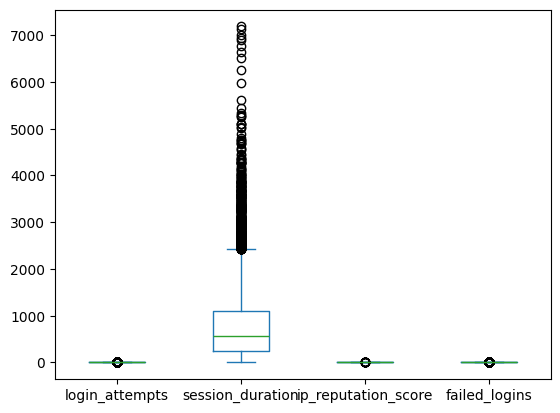

In [ ]:
#Descripción variables numérica
data.plot(kind='box')

<Axes: xlabel='encryption_used'>

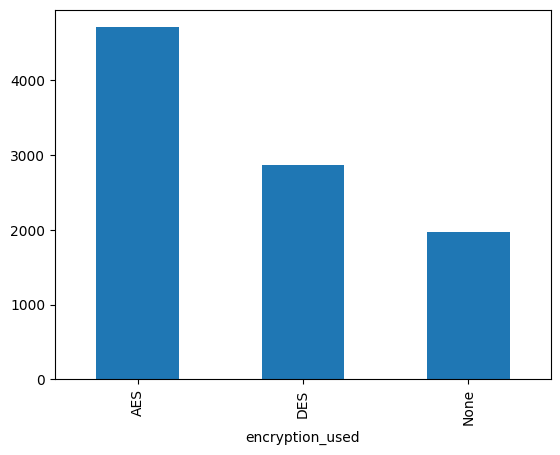

In [ ]:
#Descripción variables categóricas
data['encryption_used'].value_counts().plot(kind='bar')

<Axes: xlabel='browser_type'>

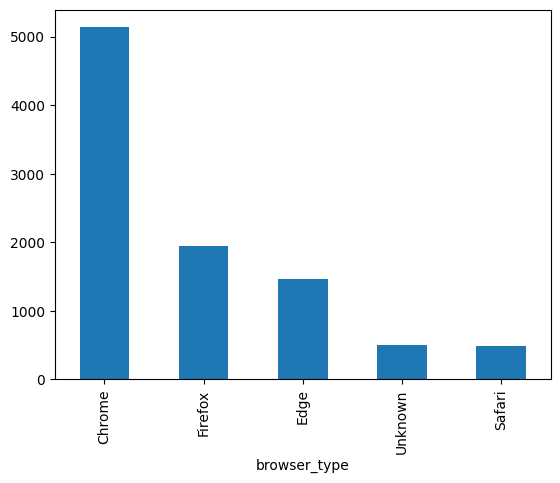

In [ ]:
#Descripción variables categóricas
data['browser_type'].value_counts().plot(kind='bar')

<Axes: xlabel='attack_detected'>

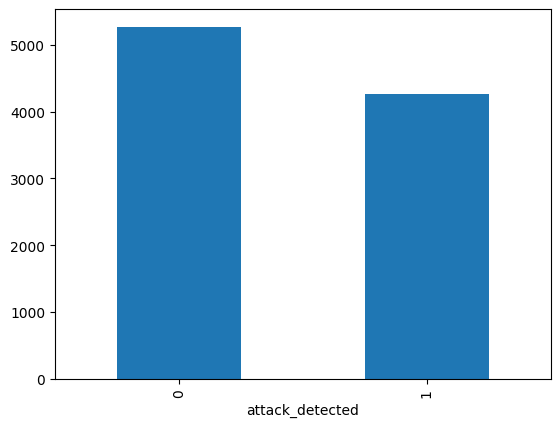

In [ ]:
#Descripción variables categóricas
data['attack_detected'].value_counts().plot(kind='bar')

#### Consideraciones sobre el Balanceo de Clases

El dataset presenta una distribución de clases de 5273 para la Clase 0 y 4264 para la Clase 1. Esto indica que las clases ya están razonablemente balanceadas (la proporción de la clase minoritaria respecto a la mayoritaria es aproximadamente 0.8).

Por lo tanto, en este caso, **no es necesario aplicar técnicas de sobremuestreo como SMOTE o SMOTENC**. Un intento previo con `SMOTENC` y una `sampling_strategy=0.2` resultó en un error, ya que esta estrategia intentaba *reducir* la clase minoritaria en lugar de aumentarla, lo cual es contrario al propósito del sobremuestreo. Se procede con el dataset original, ya que el desbalance no es significativo.

In [ ]:
### Paso de Balanceo de Clases Omitido

Dada la distribución de clases balanceada del dataset (Clase 0: 5273, Clase 1: 4264), no se aplicarán técnicas de balanceo como SMOTE o SMOTENC en este paso. Se mantiene el dataset original para el entrenamiento y evaluación de los modelos.

ValueError: The specified ratio required to remove samples from the minority class while trying to generate new samples. Please increase the ratio.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   login_attempts       9537 non-null   int64   
 1   session_duration     9537 non-null   float64 
 2   encryption_used      9537 non-null   category
 3   ip_reputation_score  9537 non-null   float64 
 4   failed_logins        9537 non-null   int64   
 5   browser_type         9537 non-null   category
 6   attack_detected      9537 non-null   category
dtypes: category(3), float64(2), int64(2)
memory usage: 326.6 KB


In [ ]:
#Dummies para las variables categóricas existentes
data = pd.get_dummies(data, columns=['encryption_used', 'browser_type'], drop_first=False, dtype=int)
data.head()

,login_attempts,session_duration,ip_reputation_score,failed_logins,attack_detected,encryption_used_AES,encryption_used_DES,encryption_used_None,browser_type_Chrome,browser_type_Edge,browser_type_Firefox,browser_type_Safari,browser_type_Unknown
0,4,492.983263,0.606818,1,1,0,1,0,0,1,0,0,0
1,3,1557.996461,0.301569,0,0,0,1,0,0,0,1,0,0
2,3,75.044262,0.739164,2,1,0,1,0,1,0,0,0,0
3,4,601.248835,0.123267,0,1,0,1,0,0,0,0,0,1
4,5,532.540888,0.054874,1,0,1,0,0,0,0,1,0,0


In [ ]:
# la variable objetivo no se le hace dummies, se le hace label encoder

#LabelEncoder para la variable objetivo
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
data["attack_detected"]=labelencoder.fit_transform(data["attack_detected"])
data.head()

,login_attempts,session_duration,ip_reputation_score,failed_logins,attack_detected,encryption_used_AES,encryption_used_DES,encryption_used_None,browser_type_Chrome,browser_type_Edge,browser_type_Firefox,browser_type_Safari,browser_type_Unknown
0,4,492.983263,0.606818,1,1,0,1,0,0,1,0,0,0
1,3,1557.996461,0.301569,0,0,0,1,0,0,0,1,0,0
2,3,75.044262,0.739164,2,1,0,1,0,1,0,0,0,0
3,4,601.248835,0.123267,0,1,0,1,0,0,0,0,0,1
4,5,532.540888,0.054874,1,0,1,0,0,0,0,1,0,0


# 2. División 70-30

Se divide el dataset en 70% para entrenamiento y 30% para prueba.

El parámetro `stratify=Y` es importante: garantiza que la proporción de clases en ambos subconjuntos sea la misma que en el dataset original. Sin esto, podría ocurrir por azar que el conjunto de prueba tenga muy pocos registros de una clase, lo que haría la evaluación poco representativa.

<Axes: xlabel='attack_detected'>

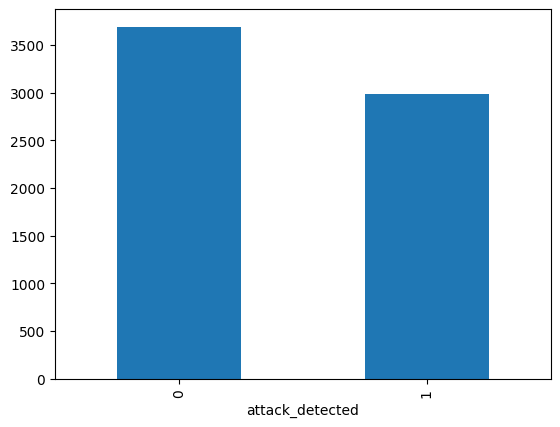

In [ ]:
#División 70-30
from sklearn.model_selection import train_test_split
X = data.drop("attack_detected", axis = 1) # Variables predictoras
Y = data['attack_detected'] #Variable objetivo
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=Y) #Muestreo estratificado    #en clasificación siempre se debe activar el muestreo estratificado
Y_train.value_counts().plot(kind='bar')

<Axes: xlabel='attack_detected'>

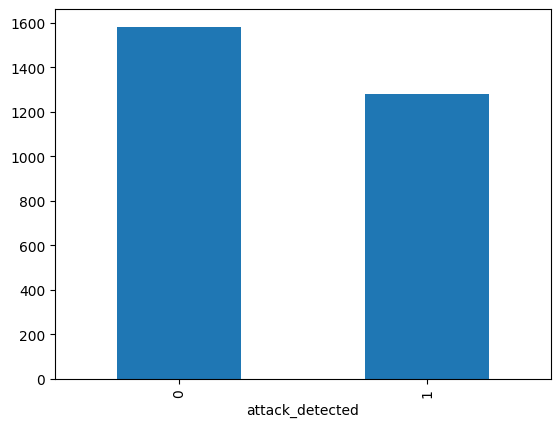

In [ ]:
#Variable objetivo del 30%

Y_test.value_counts().plot(kind='bar')

## Entrenamiento y Evaluación de Modelos

Se entrenan cinco modelos con el 70% de los datos y se evalúan con el 30% restante. Para cada uno se reportan las siguientes métricas:

- **Exactitud:** porcentaje de predicciones correctas sobre el total.
- **Precisión:** de los que el modelo predice como ataque, cuántos realmente lo son.
- **Recall:** de todos los ataques reales, cuántos logró detectar el modelo.
- **F1-score:** media armónica entre precisión y recall, útil cuando las clases están desbalanceadas.
- **Curva ROC / AUC:** mide la capacidad general del modelo para separar las dos clases.
- **Matriz de confusión:** desglose detallado de aciertos y errores por clase.

# 3. Aprendizaje con el 70% y Evaluación con el 30%


# **Tree**
No se normaliza porque pierden interpretabilidad

### Árbol de Decisión

Los árboles de decisión no requieren normalización. Sus reglas se basan en umbrales de los valores originales, por lo que normalizar no cambia el resultado pero sí hace que los umbrales pierdan su interpretación natural.

Parámetros configurados:
- `criterion='gini'`: criterio para evaluar la calidad de cada división.
- `min_samples_leaf=50`: mínimo de registros por hoja, controla el sobreajuste.
- `max_depth=10`: limita la profundidad del árbol para evitar que memorice los datos de entrenamiento.

In [ ]:
#Creación del modelo con el conjunto de entrenamiento
from sklearn.tree import DecisionTreeClassifier #DecisionTreeRegressor

modelTree = DecisionTreeClassifier(criterion='gini', min_samples_leaf=50, max_depth=10) #gini, entropy
modelTree.fit(X_train, Y_train) #70% train

DecisionTreeClassifier(max_depth=10, min_samples_leaf=50)

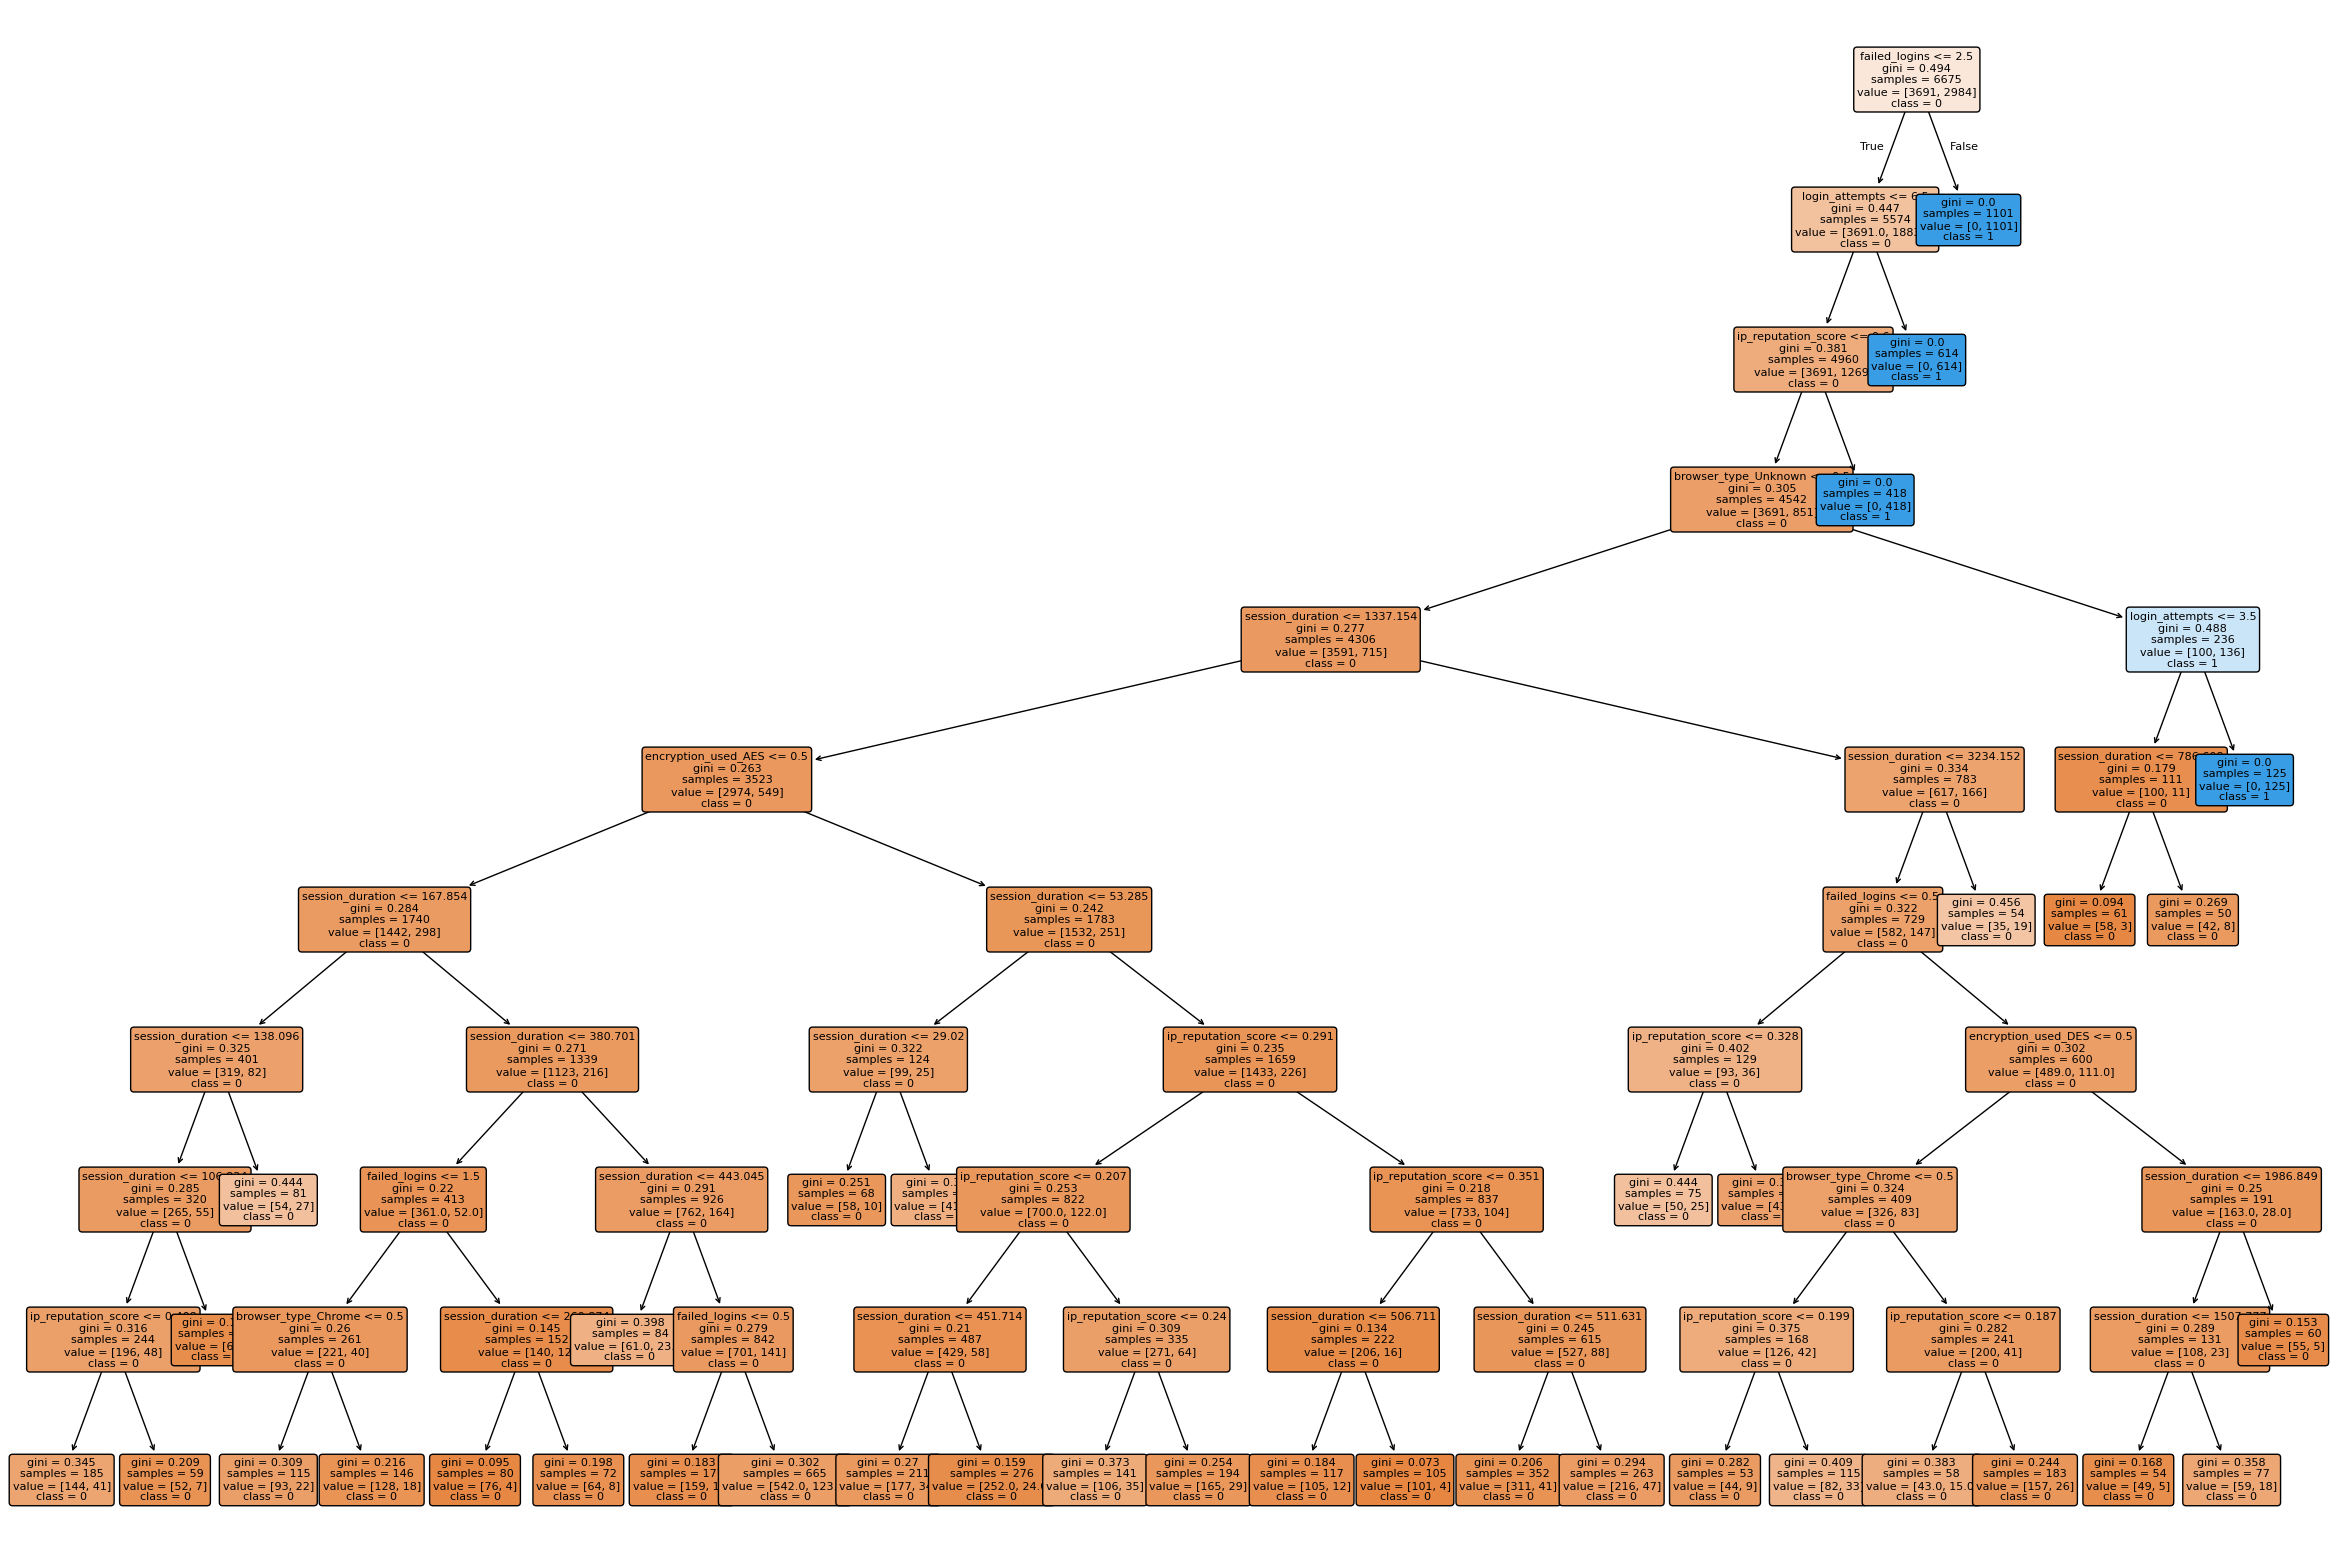

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(30,20)) #Tamaño de la imagen
plot_tree(modelTree, feature_names=X_train.columns.values, class_names=[str(c) for c in labelencoder.classes_], rounded=True,  fontsize=8, filled=True)
plt.show()

In [ ]:
#Evaluación 30% (X_test)
from sklearn import metrics

Y_pred = modelTree.predict(X_test) #30% Test
print(Y_pred)

[0 1 1 ... 1 0 1]


In [ ]:
#Exactitud: Correctos/Total
exactitud=metrics.accuracy_score(y_true=Y_test, y_pred=Y_pred)
print(exactitud)

0.8944793850454228


In [ ]:
#Matriz de confusion
from sklearn import metrics

cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
cm

array([[1582,    0],
       [ 302,  978]])

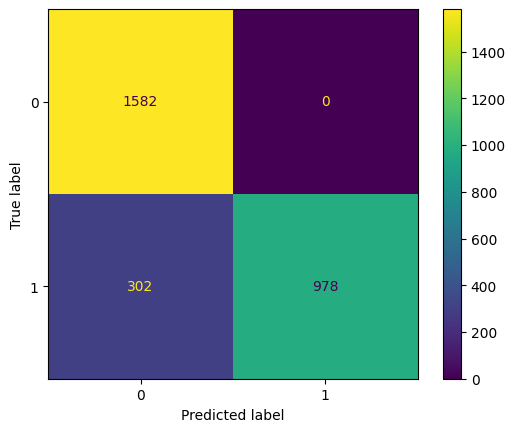

In [ ]:
#Plot de la matriz de confusion
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labelencoder.classes_)
disp.plot()

In [ ]:
#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=[str(c) for c in labelencoder.classes_]))

              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1582
           1       1.00      0.76      0.87      1280

    accuracy                           0.89      2862
   macro avg       0.92      0.88      0.89      2862
weighted avg       0.91      0.89      0.89      2862



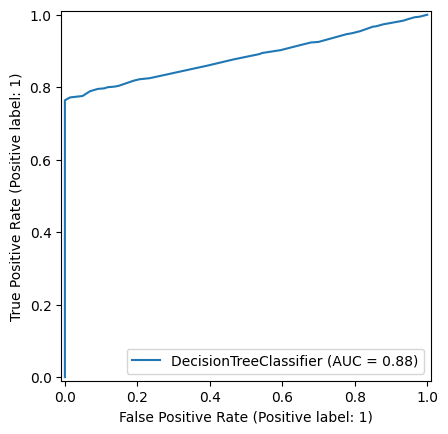

In [ ]:
metrics.RocCurveDisplay.from_estimator(modelTree,X_test, Y_test)

# **Random Forest**

Es un conjunto de múltiples árboles de decisión que votan la clase mayoritaria. Al igual que el árbol individual, no requiere normalización.

Parámetros configurados:
- `n_estimators=200`: cantidad de árboles en el bosque.
- `max_samples=0.9`: cada árbol se entrena con el 90% de los datos (muestreo con reemplazo, técnica bagging).
- `max_depth=20` y `min_samples_leaf=10`: controlan la complejidad individual de cada árbol.

También se grafica la importancia de las variables (`feature_importances_`), que indica cuánto contribuye cada una a reducir la impureza en promedio.

In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

model_rf= RandomForestClassifier(n_estimators=200,  max_samples=0.9, criterion='gini',                     #n_estimators es la cantidad de arboles
                              max_depth=20, min_samples_leaf=10)
model_rf.fit(X_train, Y_train) #70%

RandomForestClassifier(max_depth=20, max_samples=0.9, min_samples_leaf=10,
                       n_estimators=200)

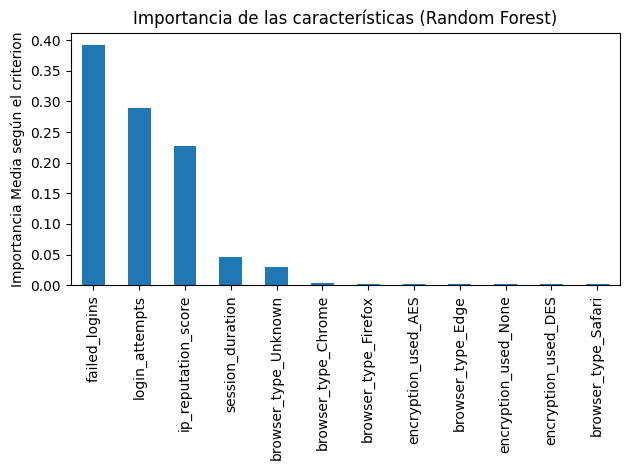

In [ ]:
#Importancia de las características
importances = model_rf.feature_importances_
feature_names = X_train.columns
forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.sort_values(ascending=False).plot.bar(ax=ax)
ax.set_title("Importancia de las características (Random Forest)")
ax.set_ylabel("Importancia Media según el criterion")
fig.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1582
           1       1.00      0.76      0.87      1280

    accuracy                           0.89      2862
   macro avg       0.92      0.88      0.89      2862
weighted avg       0.91      0.89      0.89      2862



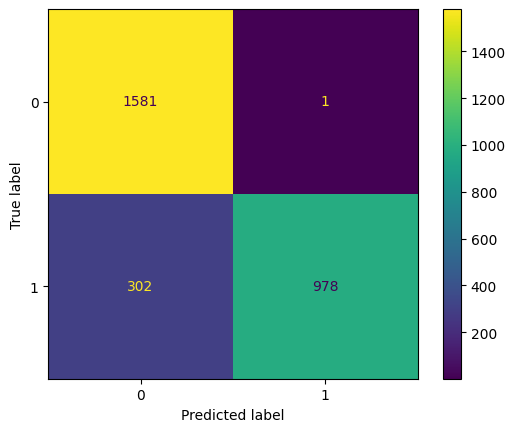

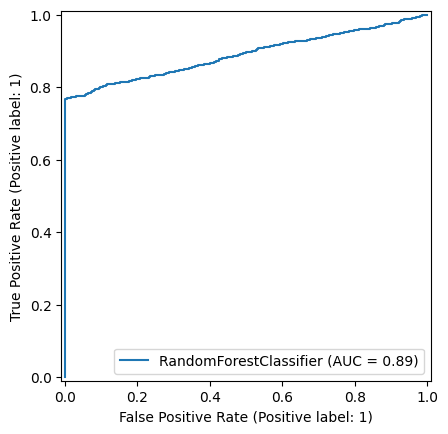

In [ ]:
#Evaluación de RandomForest con 30%
from sklearn import metrics

Y_pred = model_rf.predict(X_test) #30%

#Matriz de confusion
cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labelencoder.classes_)
disp.plot()

#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=[str(c) for c in labelencoder.classes_]))

# Curva ROC
metrics.RocCurveDisplay.from_estimator(model_rf,X_test, Y_test)

# **KNN**
* Normalización

### KNN - K-Nearest Neighbors

Clasifica cada punto según la clase más frecuente entre sus `k` vecinos más cercanos.

Este modelo es sensible a la escala de las variables porque trabaja con distancias. Si una variable tiene valores en miles y otra en decimales, la primera dominaría el cálculo. Por eso se normalizan las variables numéricas continuas con `MinMaxScaler`.

Las columnas dummy (0 y 1) no se normalizan porque ya están en la misma escala.

El scaler se ajusta (`fit`) con el 100% de los datos y luego se aplica a los conjuntos de entrenamiento y prueba por separado. Ajustarlo sobre el conjunto de prueba sería una fuga de datos.

Parámetros configurados:
- `n_neighbors=3`: número de vecinos a consultar.
- `metric='euclidean'`: distancia usada para encontrar los vecinos más cercanos.

In [ ]:
#Normalizacion las variables numéricas (las dummies no se normalizan)
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
variables_numericas=['login_attempts', 'session_duration', 'ip_reputation_score', 'failed_logins']


min_max_scaler.fit(data[variables_numericas]) #Ajuste de los parametros sobre 100% de los datos (data): max - min

#Se aplica la normalización a 70%  y 30%
X_train[variables_numericas]= min_max_scaler.transform(X_train[variables_numericas]) #70%
X_test[variables_numericas]= min_max_scaler.transform(X_test[variables_numericas]) #30%
X_train.head()

,login_attempts,session_duration,ip_reputation_score,failed_logins,encryption_used_AES,encryption_used_DES,encryption_used_None,browser_type_Chrome,browser_type_Edge,browser_type_Firefox,browser_type_Safari,browser_type_Unknown
7652,0.333333,0.244958,0.567355,0.2,0,1,0,1,0,0,0,0
6188,0.500000,0.048531,0.251210,0.4,0,1,0,0,0,0,0,1
1996,0.250000,0.031302,0.369300,0.8,0,1,0,1,0,0,0,0
7419,0.416667,0.198931,0.222315,0.4,0,0,1,0,1,0,0,0
3101,0.583333,0.040193,0.711880,0.0,0,1,0,0,0,1,0,0


In [ ]:
X_test.head()

,login_attempts,session_duration,ip_reputation_score,failed_logins,encryption_used_AES,encryption_used_DES,encryption_used_None,browser_type_Chrome,browser_type_Edge,browser_type_Firefox,browser_type_Safari,browser_type_Unknown
9041,0.166667,0.116956,0.375620,0.4,1,0,0,1,0,0,0,0
4406,0.250000,0.127181,0.139280,0.6,1,0,0,0,0,1,0,0
1299,0.250000,0.056178,0.419435,0.2,1,0,0,0,0,0,0,1
2735,0.083333,0.088937,0.178072,0.0,1,0,0,0,0,0,1,0
9161,0.250000,0.083023,0.237703,0.0,1,0,0,0,0,0,0,1


In [ ]:
#Aprendizaje KNN con 70%
from sklearn.neighbors  import KNeighborsClassifier #KNeighborsRegressor

modelKnn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')#euclidean, minkowski
modelKnn.fit(X_train, Y_train) #70%

KNeighborsClassifier(metric='euclidean', n_neighbors=3)

              precision    recall  f1-score   support

           0       0.81      0.90      0.85      1582
           1       0.85      0.75      0.80      1280

    accuracy                           0.83      2862
   macro avg       0.83      0.82      0.83      2862
weighted avg       0.83      0.83      0.83      2862



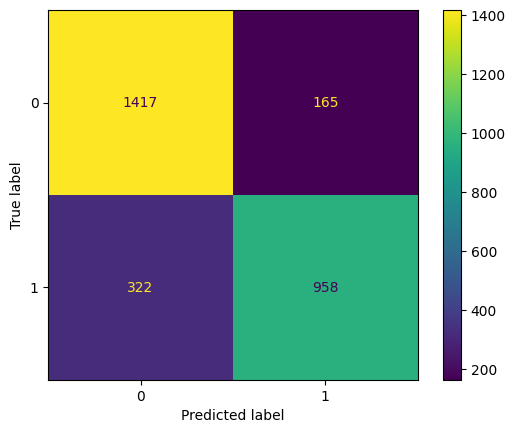

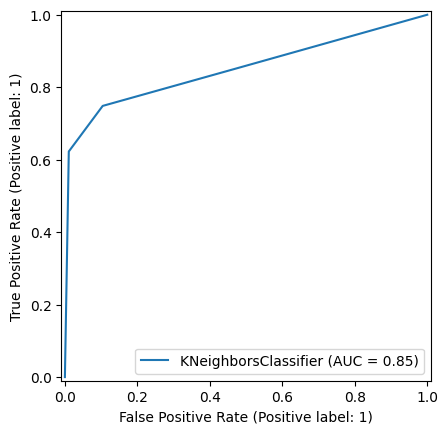

In [ ]:
#Evaluación de Knn con 30%
from sklearn import metrics

Y_pred = modelKnn.predict(X_test) #30%

#Matriz de confusion
cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labelencoder.classes_)
disp.plot()

#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=[str(c) for c in labelencoder.classes_]))

# Curva ROC
metrics.RocCurveDisplay.from_estimator(modelKnn,X_test, Y_test)

# **Red Neuronal**
- Normalizar

### Red Neuronal

Perceptrón multicapa entrenado con descenso de gradiente. Requiere normalización por la misma razón que KNN: es sensible a la escala de las variables.

Parámetros configurados:
- `activation='logistic'`: función de activación sigmoide en la capa oculta.
- `hidden_layer_sizes=(50,)`: una sola capa oculta con 50 neuronas.
- `learning_rate_init=0.02`: tamaño del paso en cada actualización de pesos.
- `momentum=0.03`: ayuda a acelerar la convergencia y evitar mínimos locales.
- `max_iter=500`: número máximo de épocas de entrenamiento.

La curva de pérdida (`loss_curve_`) permite verificar que el modelo convergió correctamente durante el entrenamiento.

In [ ]:
#Red Neuronal

from sklearn.neural_network import MLPClassifier #MLPRegressor

#Solo se configura capas ocultas, no se configura capa de entrada y de salida
#activation -> función activación de la oculta: tanh, logistic, linear, relu
#hidden_layer_sizes=5,7 -> dos capas ocultas con 5 neuronas y 7 neuronas
#learning_rate-> tamaño del paso constante o decreciente (constant, adaptive)
#learning_rate_init-> valor tasa de aprendizaje
#momentum-> valor momentum
#max_iter-> iteaciones
#random_state-> semilla para generacion numeros seudoaletorios
modelNN = MLPClassifier(activation="logistic",hidden_layer_sizes=(50), learning_rate='constant',
                     learning_rate_init=0.02, momentum= 0.03, max_iter=500, random_state=3)

modelNN.fit(X_train, Y_train) #70% normalizados


MLPClassifier(activation='logistic', hidden_layer_sizes=50,
              learning_rate_init=0.02, max_iter=500, momentum=0.03,
              random_state=3)

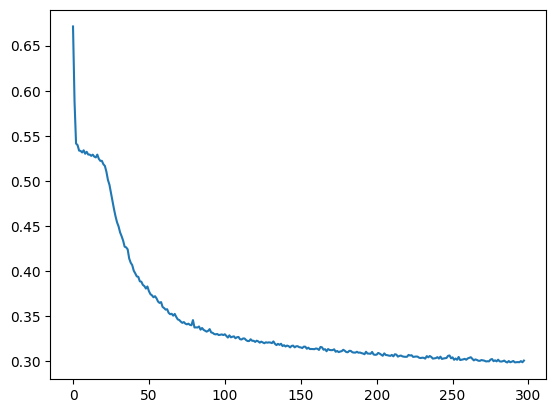

In [ ]:
#Loss es la desviación entre Y_train y el Y_pred
loss_values = modelNN.loss_curve_
plt.plot(loss_values)

              precision    recall  f1-score   support

           0       0.84      0.98      0.91      1582
           1       0.98      0.77      0.86      1280

    accuracy                           0.89      2862
   macro avg       0.91      0.88      0.88      2862
weighted avg       0.90      0.89      0.89      2862



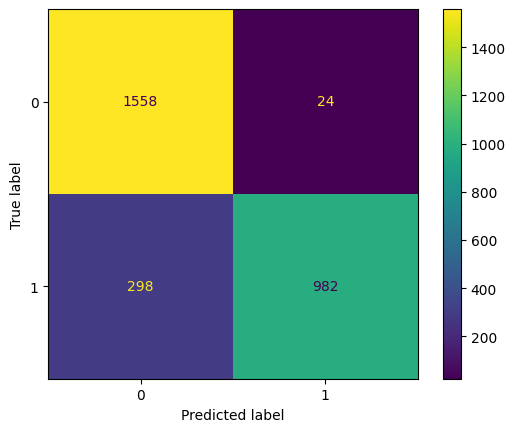

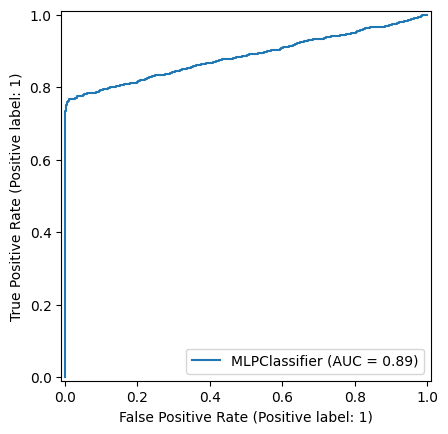

In [ ]:
#Evaluación de Red Neuronal
from sklearn import metrics

Y_pred = modelNN.predict(X_test) #30%

#Matriz de confusion
cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=[str(c) for c in labelencoder.classes_])
disp.plot()

#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=[str(c) for c in labelencoder.classes_]))

# Curva ROC
metrics.RocCurveDisplay.from_estimator(modelNN,X_test, Y_test)

In [ ]:
#Imprimir el modelo
print(modelNN.coefs_)  # W
print(modelNN.intercepts_) # b

[array([[ 4.90389721e-01,  6.80462906e+00, -6.17343295e+00,
        -3.80651842e+00,  2.73456909e-01,  9.29782670e-02,
        -2.38049222e-01,  2.43152579e+00, -7.66598762e-01,
         7.27330217e-01, -3.17771056e+00, -6.32452565e-01,
         3.74982612e-02,  2.92410482e+00,  2.03210127e+01,
         3.36749061e-01, -7.11478620e-01,  2.53104996e+01,
        -8.80487556e-01,  1.48724509e-01,  7.14403716e+00,
         8.32069667e-01, -2.17963508e+00, -1.02136553e+00,
         5.73602512e+00,  1.99105548e+00,  6.58840060e-01,
         2.15820444e-01, -8.70423789e-01,  2.77779427e+01,
         4.20113176e+00, -2.66407620e+00,  7.14224214e-01,
         4.88776263e-01,  7.32134576e-02,  1.41840984e+00,
         2.86903233e+00, -1.68325477e+00,  4.37940610e+00,
        -2.86328034e-01, -9.36956522e+00,  2.99544614e+00,
        -1.53450191e+00,  2.79261340e-01, -2.64333923e-01,
        -1.13782379e+01,  2.33200756e+00,  2.90055944e+00,
        -1.29600083e+00, -9.03797730e-01],
       [-6.5

# **SVM**
-Normalizar

### SVM - Support Vector Machine

Encuentra el hiperplano de mayor margen que separa las clases. También requiere normalización.

Parámetros configurados:
- `kernel='rbf'`: kernel de función de base radial, permite capturar relaciones no lineales entre variables.
- `C=1`: controla el balance entre maximizar el margen y penalizar errores de clasificación.
- `class_weight='balanced'`: ajusta automáticamente el peso de cada clase inversamente proporcional a su frecuencia, lo que ayuda cuando hay desbalance.

In [ ]:
#SVM
from sklearn.svm import SVC # SVR

modelSVM = SVC(kernel='rbf',C=1,class_weight="balanced") #'linear', 'poly'->degree=3, 'rbf', 'sigmoid', 'precomputed'
modelSVM.fit(X_train, Y_train) #70%

SVC(C=1, class_weight='balanced')

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1582
           1       0.86      0.76      0.81      1280

    accuracy                           0.84      2862
   macro avg       0.84      0.83      0.83      2862
weighted avg       0.84      0.84      0.84      2862



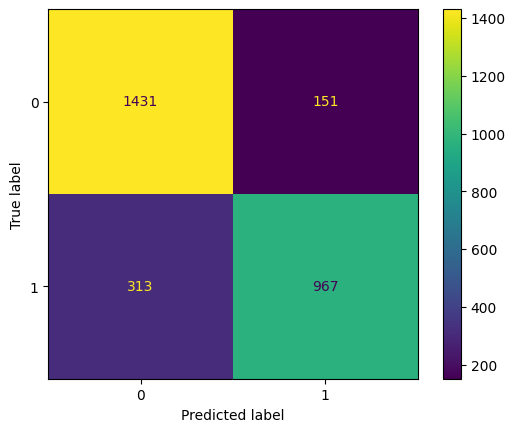

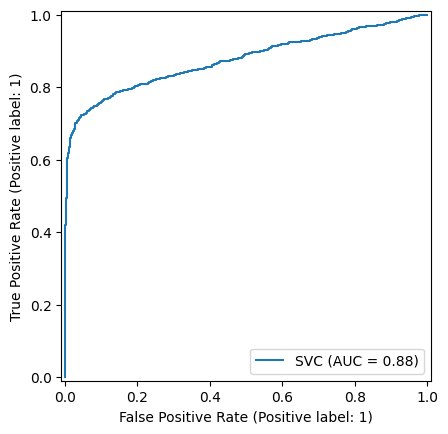

In [ ]:
#Evaluación de SVM
from sklearn import metrics

Y_pred = modelSVM.predict(X_test) #30%

#Matriz de confusion
cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=[str(c) for c in labelencoder.classes_])
disp.plot()

#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=[str(c) for c in labelencoder.classes_]))

# Curva ROC
metrics.RocCurveDisplay.from_estimator(modelSVM,X_test, Y_test)

### Por qué la Red Neuronal fue seleccionada como el mejor modelo

La Red Neuronal (`modelNN`) fue seleccionada como el modelo con mejor rendimiento debido a su balance competitivo y fuerte en varias métricas clave. Logró una precisión del 89%, con una alta precisión del 98% para detectar ataques (Clase 1), y un sólido F1-score de 0.86. Estos resultados, combinados con su capacidad para aprender patrones complejos, la convierten en la opción preferida entre los modelos evaluados (Decision Tree, Random Forest, KNN y SVM).

### Hiperparametrización con GridSearchCV para la Red neuronal

## 4. Hiperparametrización con GridSearchCV

`GridSearchCV` prueba exhaustivamente todas las combinaciones posibles de hiperparámetros usando validación cruzada con 3 folds. El parámetro `n_jobs=-1` usa todos los núcleos del procesador para correr las combinaciones en paralelo.

Se exploran combinaciones de: solver, función de activación, tasa de aprendizaje, momentum, tamaño de capas ocultas e iteraciones máximas.

El resultado fue que el modelo hiperparametrizado obtuvo 89.13% de exactitud frente al 89.45% del modelo inicial. La búsqueda además generó advertencias de inestabilidad numérica con ciertas combinaciones. Por esto se mantiene el modelo inicial como el definitivo.

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

# `modelNNH` es solo un nombre para el estimador base, el GridSearchCV probará diferentes configuraciones
modelNNH = MLPClassifier(random_state=1) # Inicializar con un modelo base, random_state para reproducibilidad

# Definir los parámetros para MLPClassifier
random_state=[1] # Semilla para generar números pseudoaleatorios
solver=['sgd','adam'] # 'lbfgs' es un solver para MLPClassifier,
learning_rate=['constant', 'adaptive'] # Tasa de aprendizaje 'adaptive'
learning_rate_init=[0.4, 1.2, 1.6] # Valor de la tasa de aprendizaje
momentum=[0.3, 0.5] # Momentum 0-1
activation=['logistic', 'identity', 'relu'] # 'logistic', 'relu', 'identity', 'tanh'
hidden_layer_sizes=[4, 20,[8, 20]] # Neuronas de la capa oculta ((entrada+salida)/2) - usando tuplas como espera MLPClassifier
max_iter = [150, 350] # Iteraciones

# Definir el scoring y cv (folds de validación cruzada) para GridSearchCV
scoring = 'accuracy' # Métrica de scoring común para clasificación
cv = 3 # Número de folds de validación cruzada, se puede ajustar

#Grid
param_grid = dict(random_state=random_state,solver=solver,activation=activation, hidden_layer_sizes=hidden_layer_sizes, max_iter=max_iter, learning_rate=learning_rate,
                  learning_rate_init=learning_rate_init, momentum=momentum)
grid = GridSearchCV(estimator=modelNNH, param_grid=param_grid, scoring=scoring, n_jobs=-1, cv=cv)
# Modificación clave: usar X_train y Y_train (datos ya escalados) para el GridSearchCV
grid.fit(X_train, Y_train)

#Mejor modelo
modelNN= grid.best_estimator_

#Medida de evaluación del mejor modelo
# Asegurarse de que medidas_CV esté inicializado si aún no existe
if 'medidas_CV' not in locals():
    medidas_CV = {}
medidas_CV['NN']=grid.best_score_

# Mejores parámetros
print( grid.best_params_)

print(medidas_CV)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
44 fits failed out of a total of 1296.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
44 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py", line 754, in fit
    return

{'activation': 'relu', 'hidden_layer_sizes': 20, 'learning_rate': 'adaptive', 'learning_rate_init': 1.6, 'max_iter': 150, 'momentum': 0.5, 'random_state': 1, 'solver': 'sgd'}
{'NN': np.float64(0.8880898876404495)}


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
medidas_CV

{'NN': np.float64(0.8880898876404495)}

### Evaluación de la Red Neuronal Hiperparametrizada en el conjunto de prueba

              precision    recall  f1-score   support

           0       0.84      0.99      0.91      1582
           1       0.99      0.76      0.86      1280

    accuracy                           0.89      2862
   macro avg       0.91      0.88      0.89      2862
weighted avg       0.91      0.89      0.89      2862

Exactitud del modelo hiperparametrizado en el conjunto de prueba: 0.8913347309573725


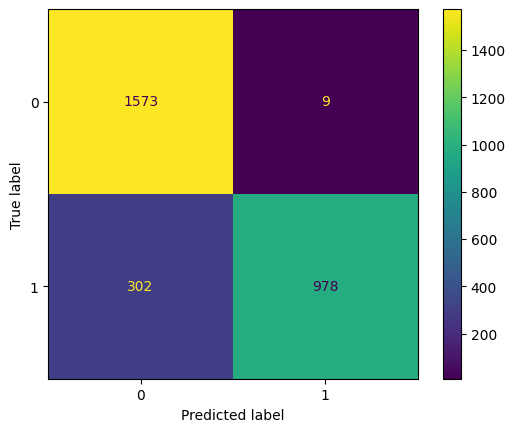

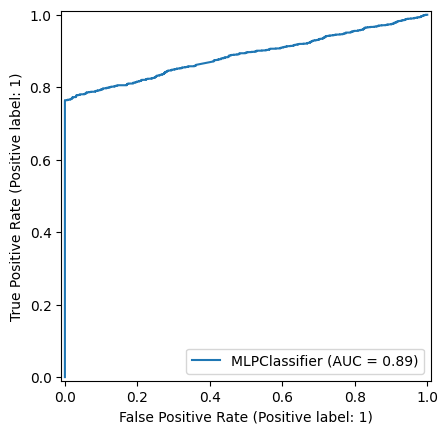

In [ ]:
from sklearn import metrics

Y_pred_hyper = modelNN.predict(X_test) # 30% con el modelo hiperparametrizado

# Matriz de confusión
cm_hyper = metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred_hyper)
disp_hyper = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_hyper, display_labels=[str(c) for c in labelencoder.classes_])
disp_hyper.plot()

# Precision, Recall, f1, exactitud
print(metrics.classification_report(y_true=Y_test, y_pred=Y_pred_hyper, target_names=[str(c) for c in labelencoder.classes_]))

# Curva ROC
metrics.RocCurveDisplay.from_estimator(modelNN, X_test, Y_test)

# Guardar la exactitud para comparación futura
exactitud_hyper = metrics.accuracy_score(y_true=Y_test, y_pred=Y_pred_hyper)
print(f"Exactitud del modelo hiperparametrizado en el conjunto de prueba: {exactitud_hyper}")

# 5. Guardamos el mejor modelo
Se entrena modelo final con 100% de los datos (X,Y)

### Justificación de los Resultados de la Red Neuronal Hiperparametrizada

Los resultados de la hiperparametrización con `GridSearchCV` para la Red Neuronal mostraron un rendimiento muy similar o ligeramente inferior al modelo de Red Neuronal inicial en el conjunto de prueba. A pesar del proceso de búsqueda de hiperparámetros, la precisión en el conjunto de prueba para el modelo hiperparametrizado fue del 89.13%, mientras que el modelo inicial obtuvo una precisión del 89.45%.

Específicamente para la detección de ataques (Clase 1):
*   **Modelo Inicial:** Precisión de 0.98, Recall de 0.77, F1-score de 0.86.
*   **Modelo Hiperparametrizado:** Precisión de 0.99, Recall de 0.76, F1-score de 0.86.

Aunque el modelo hiperparametrizado mostró una ligera mejora en la precisión de la Clase 1, tuvo un recall marginalmente menor y una precisión general también ligeramente inferior. Además, durante el proceso de `GridSearchCV` se encontraron advertencias (`ValueError: Solver produced non-finite parameter weights` y `ConvergenceWarning`), lo que indica inestabilidad numérica o problemas de convergencia con ciertas combinaciones de hiperparámetros.

En conclusión, la hiperparametrización no logró mejorar de manera consistente el rendimiento del modelo base y, en algunos aspectos, el modelo inicial demostró ser ligeramente superior o igualmente robusto en el conjunto de prueba. Por lo tanto, se mantiene la preferencia por el modelo de Red Neuronal inicial por su estabilidad y rendimiento.

In [ ]:
#Normalizar X en caso de ser necesario: Knn, NN, SVM, Reg
X[variables_numericas]= min_max_scaler.transform(X[variables_numericas])

si se selecciona arbol o random forest no se normaliza X

In [ ]:
#Entrenamos modelo final
modelNN.fit(X, Y) #100%

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=20, learning_rate='adaptive',
              learning_rate_init=1.6, max_iter=150, momentum=0.5,
              random_state=1, solver='sgd')

## 5. Guardar el Modelo

El modelo final se reentrena con el 100% de los datos para aprovechar toda la información disponible antes de guardarlo.

Se serializa con `pickle` un paquete con cuatro objetos, todos necesarios para el despliegue:

- `modelNN`: el modelo entrenado.
- `labelencoder`: para convertir la predicción numérica de vuelta a la etiqueta original.
- `variables`: lista de columnas que el modelo espera recibir, en el orden correcto.
- `min_max_scaler`: para normalizar nuevos datos con exactamente los mismos parámetros usados en el entrenamiento. Crear un scaler nuevo en despliegue daría resultados incorrectos.

In [ ]:
import pickle
filename = 'modelo-classNN.pkl'
variables= X.columns._values
pickle.dump([modelNN, labelencoder,variables,min_max_scaler], open(filename, 'wb'))